# Leitura e Manipulação de Dados

---



## Importação de Dados

Antes de qualquer análise, é preciso trazer os dados de um arquivo para dentro do Python. A biblioteca Pandas é uma das principais ferramentas usadas para isso, e sua função básica de leitura é o ```pd.read_csv()```.

Na prática, você normalmente vai importar uma base a partir de um arquivo CSV, como no exemplo abaixo:

```dados = pd.read_csv('pacientes.csv')```

Neste material, porém, vamos criar a base fictícia diretamente no código, usando ```pd.DataFrame()```.

In [82]:
import pandas as pd
import numpy as np

# database utilizada nos exemplos
dados = pd.DataFrame({
    "paciente": ["Ana Lima", "João Souza", "Maria Costa", "Carlos Souza", "Fernanda Alves", "Lucas Rocha", "Beatriz Santos", "João Souza"],
    "idade": [45, 62, 38, 55, 29, 71, -8, 62],
    "glicemia": [99.5, 140.1, np.nan, 115.0, 88.0, 158.0, 105.0, 140.1],
    "sangue": ["A+", "O+", "B+", "AB+", "O-", "A-", "B-", "O+"],
    "cidade": ["Campina Grande", "João Pessoa", "Recife", "Natal", "Fortaleza", "Recife", "Campina Grande", "João Pessoa"],
    "sexo": ["F", "Masc", "Feminino", "M", "F", "M", "Feminino", "Masc"],
    "data_admissao": ["2024-01-15", "2024-02-10", "2024-01-20", "2024-02-10", "2024-03-01", "2024-01-05", "2024-02-28", "2024-02-10"],
    "data_exame": ["20/01/2024", "15/02/2024", "25/01/2024", "15/02/2024", "05/03/2024", "10/01/2024", "05/03/2024", "15/02/2024"],
    "diagnostico": ["Diabetes Tipo 2", "Hipertensao", "Gripe Forte", "Hipertensao", "Avaliacao", "Diabetes Tipo 1", "Enxaqueca", "Hipertensao"],
    "creatinina": [0.85, 1.30, 0.71, 0, 1.00, np.nan, 0.80, 1.30]
})

## Ajustes ao Importar CSV

O CSV é um dos formatos mais comuns para troca de dados tabulares, mas frequentemente exige ajustes na hora da leitura.


```dados_CSV = pd.read_csv('pacientes.csv')```

### Separador (sep)

Define o caractere que divide as colunas. Bases brasileiras costumam adotar ```';'``` em vez de ```','``` para evitar conflito com a vírgula usada como separador decimal.

```dados_CSV = pd.read_csv('pacientes.csv', sep=';')```

### Separador decimal (decimal)

Além do separador de colunas, bases brasileiras costumam usar vírgula como separador decimal (ex.: "36,5" para temperatura, "72,3" para peso).

```dados_CSV = pd.read_csv('pacientes.csv', sep=';', decimal=',')```

### Pular linhas (skiprows)

Ignora um número determinado de linhas no início do arquivo, útil quando há notas ou metadados antes do cabeçalho real.

```dados_CSV = pd.read_csv('pacientes.csv', sep=';', skiprows=1)```

### Codificação de caracteres (encoding)

Previne e corrige problemas com acentuação gráfica. Codificações habituais incluem latin1, utf-8 e cp1252.

```dados_CSV = pd.read_csv('pacientes.csv', sep=';', encoding='latin1')```

### Selecionar colunas específicas (usecols)

Permite carregar apenas as colunas necessárias, reduzindo o consumo de memória.

```dados_CSV = pd.read_csv('pacientes.csv', usecols=[0, 1, 2])```

### Excluindo uma coluna já importada

Uma coluna pode ser excluída após a importação via ```.drop()```. O parâmetro axis=1 indica coluna e axis=0 linha.

```dados_CSV = dados.drop('UBS', axis=1)```

## Outros Formatos de Arquivo

O Pandas possui métodos integrados para carregar múltiplos formatos estruturados:

```dados_json = pd.read_json('pacientes.json') # JSON```

```dados_xml = pd.read_xml('pacientes.xml') # XML```

```dados_xlsx = pd.read_excel('pacientes.xlsx') # Excel```

## Dicionário de Dados

O dicionário de dados explica a especificação de cada variável presente na tabela:

| Variável | Tipo | Descrição |
|---|---|---|
| `paciente` | Categórica | Nome do paciente |
| `idade` | Numérica | Idade do paciente, em anos |
| `glicemia` | Numérica | Nível de glicemia no sangue (mg/dL) |
| `sexo` | Categórica | Sexo do paciente |
| `diagnostico` | Categórica | Diagnóstico clínico associado ao atendimento |
| `creatinina` | Numérica | Nível de creatinina no sangue (mg/dL), indicador da função renal |

O documento também pode ser chamado de catálogo de dados, especificação técnica ou glossário de variáveis.



---



## Identificação e Compreensão dos Dados

### Estrutura geral

In [89]:
dados.columns # Nomes das colunas
dados.info() # Tipos das colunas e contagem de valores nao nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   paciente       8 non-null      object 
 1   idade          8 non-null      int64  
 2   glicemia       7 non-null      float64
 3   sangue         8 non-null      object 
 4   cidade         8 non-null      object 
 5   sexo           8 non-null      object 
 6   data_admissao  8 non-null      object 
 7   data_exame     8 non-null      object 
 8   diagnostico    8 non-null      object 
 9   creatinina     7 non-null      float64
dtypes: float64(2), int64(1), object(7)
memory usage: 772.0+ bytes


### Visualização rápida

In [39]:
dados.head() # Primeiras 5 linhas

,paciente,idade,glicemia,sangue,cidade,sexo,data_admissao,data_exame,diagnostico,creatinina
0,Ana Lima,45,99.5,A+,Campina Grande,F,2024-01-15,20/01/2024,Diabetes Tipo 2,0.85
1,João Souza,62,140.1,O+,João Pessoa,Masc,2024-02-10,15/02/2024,Hipertensao,1.30
2,Maria Costa,38,NaN,B+,Recife,Feminino,2024-01-20,25/01/2024,Gripe Forte,0.71
3,Carlos Souza,55,115.0,AB+,Natal,M,2024-02-10,15/02/2024,Hipertensao,0.00
4,Fernanda Alves,29,88.0,O-,Fortaleza,F,2024-03-01,05/03/2024,Avaliacao,1.00


In [40]:
dados.tail() # Ultimas 5 linhas

,paciente,idade,glicemia,sangue,cidade,sexo,data_admissao,data_exame,diagnostico,creatinina
3,Carlos Souza,55,115.0,AB+,Natal,M,2024-02-10,15/02/2024,Hipertensao,0.0
4,Fernanda Alves,29,88.0,O-,Fortaleza,F,2024-03-01,05/03/2024,Avaliacao,1.0
5,Lucas Rocha,71,158.0,A-,Recife,M,2024-01-05,10/01/2024,Diabetes Tipo 1,NaN
6,Beatriz Santos,-8,105.0,B-,Campina Grande,Feminino,2024-02-28,05/03/2024,Enxaqueca,0.8
7,João Souza,62,140.1,O+,João Pessoa,Masc,2024-02-10,15/02/2024,Hipertensao,1.3


In [41]:
dados.sample(3) # Amostra aleatoria de 3 registros

,paciente,idade,glicemia,sangue,cidade,sexo,data_admissao,data_exame,diagnostico,creatinina
5,Lucas Rocha,71,158.0,A-,Recife,M,2024-01-05,10/01/2024,Diabetes Tipo 1,NaN
6,Beatriz Santos,-8,105.0,B-,Campina Grande,Feminino,2024-02-28,05/03/2024,Enxaqueca,0.80
0,Ana Lima,45,99.5,A+,Campina Grande,F,2024-01-15,20/01/2024,Diabetes Tipo 2,0.85


### Exploração de Categorias

Antes de filtrar ou agrupar uma coluna categórica, é útil verificar quais valores ela contém e com que frequência aparecem.

In [87]:
dados.sangue.unique()        # Lista os valores distintos da coluna

array(['A+', 'O+', 'B+', 'AB+', 'O-', 'A-', 'B-'], dtype=object)

In [43]:
dados.sangue.nunique()       # Conta quantos valores distintos existem

7

In [44]:
dados.sangue.value_counts()  # Conta a frequência de cada valor

,count
sangue,
O+,2
A+,1
B+,1
AB+,1
O-,1
A-,1
B-,1


### Identificando e removendo duplicatas

In [73]:
# Identifica todas as linhas duplicadas
dados[dados.duplicated(['paciente', 'data_admissao'], keep=False)]

,paciente,idade,glicemia,sangue,cidade,sexo,data_admissao,data_exame,diagnostico,creatinina


In [72]:
# Remove mantendo a primeira ocorrencia
dados.drop_duplicates(subset=['paciente', 'data_admissao'], keep='first', inplace=True)



---



## Tratamento de Dados Ausentes

Células vazias ou preenchidas com NaN precisam ser examinadas antes da decisão de descarte ou preenchimento.

Nem sempre a ausência é uma célula vazia. Em dados de saúde pública, códigos como 9, 99 ou textos como "IGNORADO" indicam ausência de resposta.

### Contagem de ausências com ```.isnull().sum()```

In [83]:
dados.isnull().sum()

,0
paciente,0
idade,0
glicemia,1
sangue,0
cidade,0
sexo,0
data_admissao,0
data_exame,0
diagnostico,0
creatinina,1


### Remoção com ```.dropna()```

In [76]:
# Remove a linha se QUALQUER coluna estiver vazia
dados_sem_nulos = dados.dropna(how='any')

# Remove a linha apenas se TODAS as colunas estiverem vazias
dados_sem_linhas_vazias = dados.dropna(how='all')

# Aplica o criterio apenas a coluna especificada
dados_validos = dados.dropna(how='any', subset=['idade'])

### Preenchimento com ```.fillna()```

Substitui ausências por estimativas estatísticas da distribuição.

In [77]:
mediana = dados.glicemia.median()
dados.glicemia = dados.glicemia.fillna(mediana)

A mediana não sofre distorções causadas por valores extremos (outliers), sendo mais recomendada que a média em distribuições assimétricas.

### Recodificando dados para ausente ```(NaN)```

Converte códigos que representam ausência em ```NaN``` explícito para não poluir cálculos matemáticos futuros.

In [79]:
dados.creatinina = dados.creatinina.replace(0, np.nan)



---



## Identificação de Outliers

Outliers são valores atípicos que se distanciam muito da distribuição. Podem ser:
*   **Erro:** Falha de digitação ou medição (ex.: idade de 200 anos).
*   **Caso real e raro:** Fenômeno autêntico extremo (ex.: recém-nascido com peso muito baixo por prematuridade).



### Resumo estatístico com ```.describe()```

In [86]:
dados.describe()

,idade,glicemia,creatinina
count,8.000000,7.000000,7.000000
mean,44.250000,120.814286,0.851429
std,25.251591,25.630804,0.441981
min,-8.000000,88.000000,0.000000
25%,35.750000,102.250000,0.755000
50%,50.000000,115.000000,0.850000
75%,62.000000,140.100000,1.150000
max,71.000000,158.000000,1.300000


Resume o comportamento estatístico das colunas numéricas, incluindo quantidade de valores válidos (não nulos), média aritmética e desvio padrão, limites inferior e superior encontrados e quartis da distribuição.



---



## Formatação dos Dados



### Mapeando códigos para rótulos legíveis

In [88]:
dados.sexo.unique()

array(['F', 'Masc', 'Feminino', 'M'], dtype=object)

In [52]:
dados.sexo = dados.sexo.replace('F', 'Feminino')
dados.sexo = dados.sexo.replace('M', 'Masculino')
dados.sexo = dados.sexo.replace('Masc', 'Masculino')

### Arredondamento e conversão de datas


In [53]:
dados.glicemia = dados.glicemia.round(1)
dados.data_admissao = pd.to_datetime(dados.data_admissao)
dados.data_exame = pd.to_datetime(dados.data_exame, format='%d/%m/%Y')

### Limpeza e padronização textual

In [54]:
# Remove espacos em branco no inicio e no fim
dados.paciente = dados.paciente.str.strip()

Você pode utilizar ```.str.upper()``` ou ```.str.lower()``` para uniformizar a caixa do texto e ```.str.replace()``` para tratar grafias divergentes de um mesmo município ou categoria.



---



## Seleção e Filtro de Dados

Depois que a base já está limpa, é comum precisar analisar apenas uma fatia dos registros.

### Maiores e menores valores

In [55]:
dados.nlargest(5, 'idade')
dados.nsmallest(5, 'idade')

,paciente,idade,glicemia,sangue,cidade,sexo,data_admissao,data_exame,diagnostico,creatinina
6,Beatriz Santos,-8,105.0,B-,Campina Grande,Feminino,2024-02-28,2024-03-05,Enxaqueca,0.80
4,Fernanda Alves,29,88.0,O-,Fortaleza,Feminino,2024-03-01,2024-03-05,Avaliacao,1.00
2,Maria Costa,38,110.0,B+,Recife,Feminino,2024-01-20,2024-01-25,Gripe Forte,0.71
0,Ana Lima,45,99.5,A+,Campina Grande,Feminino,2024-01-15,2024-01-20,Diabetes Tipo 2,0.85
3,Carlos Souza,55,115.0,AB+,Natal,Masculino,2024-02-10,2024-02-15,Hipertensao,NaN


### Filtro por condição lógica

In [56]:
adultos = dados[dados.idade >= 18]
adultos_recife = dados[(dados.idade >= 18) & (dados.cidade == 'Recife')]

Use ```&``` para “E” (ambas as condições precisam ser verdadeiras) e ```|``` para “OU” (basta uma ser verdadeira).

### Filtro por texto parcial

In [57]:
dados2 = dados[dados.paciente.str.contains('Souza', na=False)]

O parâmetro ```na=False``` evita erros quando há valores ausentes na coluna de texto. Sem ele, o Pandas gera exceção ao tentar comparar um ```NaN``` com a string de busca.

### Filtro por múltiplas categorias

Quando é preciso selecionar registros que pertencem a uma lista de categorias, usa-se ```.isin()``` em vez de escrever várias condições com ```|```.

In [58]:
municipios_paraiba = ['Campina Grande', 'João Pessoa']
dados_paraiba = dados[dados.cidade.isin(municipios_paraiba)]



---



## Criação de Novas Variáveis

### Coluna condicional via ```.loc```

In [59]:
dados.loc[dados.glicemia < 100, 'FAIXA_GLICEMIA'] = 'Normal'
dados.loc[dados.glicemia >= 100, 'FAIXA_GLICEMIA'] = 'Alterada'

### Coluna calculada com ```.assign()```

In [60]:
dados = dados.assign(GLICEMIA_MG_L = dados.glicemia * 10)

### Faixas categóricas com ```pd.cut()```

Transforma uma variável quantitativa contínua em intervalos categóricos bem definidos. bins estabelece os limites dos intervalos, enquanto labels nomeia cada faixa.

In [61]:
dados['FAIXA_ETARIA'] = pd.cut(
    dados.idade,
    bins=[0, 17, 59, 120],
    labels=['0-17', '18-59', '60+']
)

### Ajustando valores impossíveis para nulo

In [62]:
dados.loc[dados.idade < 0, 'idade'] = np.nan

Segue a mesma lógica vista na identificação de outliers: ao detectar um valor incoerente, converte-se o registro para ```NaN``` para tratá-lo via ```.dropna()``` ou ```.fillna()```.



---



## Agrupamento e Cálculo de Indicadores

O método ```.groupby()``` agrupa os registros por uma coluna categórica; em seguida, aplica-se uma função de agregação (```.mean()```, ```.sum()```, ```.size()```, entre outras) para resumir os dados de cada grupo.

In [63]:
dados.groupby('FAIXA_ETARIA', observed=True).glicemia.mean()
dados.groupby('cidade').size()

,0
cidade,
Campina Grande,2
Fortaleza,1
João Pessoa,1
Natal,1
Recife,2




---



## Criação de Gráficos

A criação de gráficos de apoio complementa a análise ao evidenciar padrões de dispersão e assimetrias.

In [64]:
import matplotlib.pyplot as plt

### Histograma após ```.describe()```

Gerar um histograma logo após ```.describe()``` valida visualmente a concentração dos dados e aponta a presença de valores discrepantes.


In [65]:
dados.describe()

,idade,glicemia,data_admissao,data_exame,creatinina,GLICEMIA_MG_L
count,6.000000,7.000000,7,7,5.000000,7.000000
mean,50.000000,116.514286,2024-02-03 13:42:51.428571392,2024-02-08 13:42:51.428571392,0.932000,1165.142857
min,29.000000,88.000000,2024-01-05 00:00:00,2024-01-10 00:00:00,0.710000,880.000000
25%,39.750000,102.250000,2024-01-17 12:00:00,2024-01-22 12:00:00,0.800000,1022.500000
50%,50.000000,110.000000,2024-02-10 00:00:00,2024-02-15 00:00:00,0.850000,1100.000000
75%,60.250000,127.550000,2024-02-19 00:00:00,2024-02-24 12:00:00,1.000000,1275.500000
max,71.000000,158.000000,2024-03-01 00:00:00,2024-03-05 00:00:00,1.300000,1580.000000
std,15.620499,24.348883,NaN,NaN,0.231019,243.488828


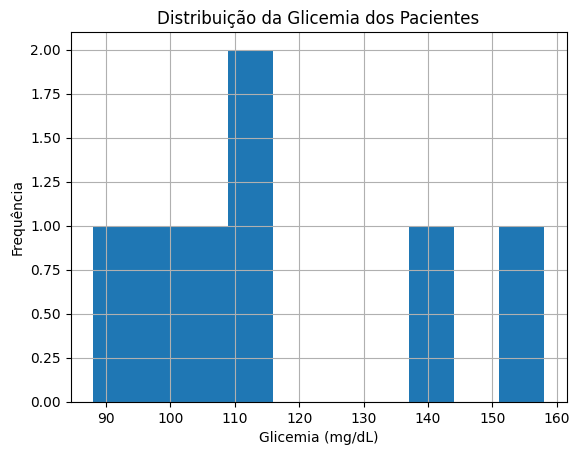

In [66]:
dados['glicemia'].hist()
plt.title('Distribuição da Glicemia dos Pacientes')
plt.xlabel('Glicemia (mg/dL)')
plt.ylabel('Frequência')
plt.show()

### Gráfico de barras após ```.value_counts()```

O método ```.value_counts()``` quantifica a frequência absoluta de cada categoria e ```.plot.bar()``` plota esses totais em colunas para comparação direta.

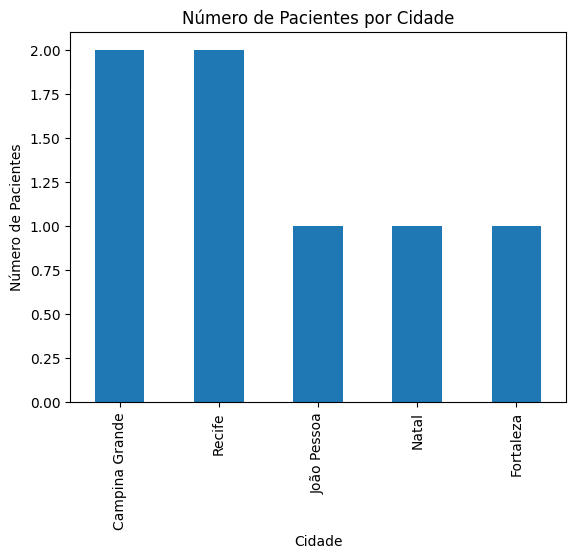

In [67]:
dados['cidade'].value_counts().plot.bar()
plt.title('Número de Pacientes por Cidade')
plt.xlabel('Cidade')
plt.ylabel('Número de Pacientes')
plt.show()



---



## Verificação Final e Exportação

Antes da exportação, confirme o estado final da base reexaminando a estrutura e os resumos numéricos:

In [68]:
dados.info()
dados.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 7 entries, 0 to 6
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   paciente        7 non-null      object        
 1   idade           6 non-null      float64       
 2   glicemia        7 non-null      float64       
 3   sangue          7 non-null      object        
 4   cidade          7 non-null      object        
 5   sexo            7 non-null      object        
 6   data_admissao   7 non-null      datetime64[ns]
 7   data_exame      7 non-null      datetime64[ns]
 8   diagnostico     7 non-null      object        
 9   creatinina      5 non-null      float64       
 10  FAIXA_GLICEMIA  7 non-null      object        
 11  GLICEMIA_MG_L   7 non-null      float64       
 12  FAIXA_ETARIA    6 non-null      category      
dtypes: category(1), datetime64[ns](2), float64(4), object(6)
memory usage: 867.0+ bytes


,idade,glicemia,data_admissao,data_exame,creatinina,GLICEMIA_MG_L
count,6.000000,7.000000,7,7,5.000000,7.000000
mean,50.000000,116.514286,2024-02-03 13:42:51.428571392,2024-02-08 13:42:51.428571392,0.932000,1165.142857
min,29.000000,88.000000,2024-01-05 00:00:00,2024-01-10 00:00:00,0.710000,880.000000
25%,39.750000,102.250000,2024-01-17 12:00:00,2024-01-22 12:00:00,0.800000,1022.500000
50%,50.000000,110.000000,2024-02-10 00:00:00,2024-02-15 00:00:00,0.850000,1100.000000
75%,60.250000,127.550000,2024-02-19 00:00:00,2024-02-24 12:00:00,1.000000,1275.500000
max,71.000000,158.000000,2024-03-01 00:00:00,2024-03-05 00:00:00,1.300000,1580.000000
std,15.620499,24.348883,NaN,NaN,0.231019,243.488828


Valide se os tipos de dados permanecem corretos, se não restaram valores ausentes sem tratamento e se outliers críticos foram devidamente saneados.

### Exportando a base tratada

In [69]:
dados.to_csv('base_tratada.csv', index=False)
dados.to_excel('base_tratada.xlsx', index=False)

Sempre salve os resultados tratados em um arquivo com nome diferente do arquivo original para preservar a fonte primária.